# Optimize measurement schedules with AlphaSyndrome

A set of stabilizer checks does not uniquely determine its syndrome-extraction circuit.
The order in which each ancilla interacts with data qubits changes how an ancilla fault can spread, so two schedules for the same checks can have different logical error rates.

`AlphaSyndrome`, introduced in [arXiv:2601.12509](https://arxiv.org/abs/2601.12509), uses Monte Carlo tree search to choose a schedule for a supplied noise model and decoder.
This notebook keeps the code, noise model, and decoder fixed while comparing one searched schedule with the default edge-coloring schedule.
Its deliberately small search budget demonstrates the API rather than reproducing the paper's optimization.


## Setup

Run the next cell once in a fresh notebook environment.
IPython's `%pip` magic installs into the active kernel, so the following imports use the same environment.


In [1]:
%%capture
%pip install qldpc matplotlib

In [2]:
import os
from collections.abc import Sequence

import matplotlib.pyplot as plt
import numpy as np
import sinter
from matplotlib.axes import Axes
from matplotlib.figure import Figure

from qldpc import circuits, codes, decoders

NUM_WORKERS = max(1, min(4, (os.cpu_count() or 1) - 1))

In [3]:
def run_memory_experiments(
    code: codes.CSSCode,
    strategies: Sequence[circuits.SyndromeMeasurementStrategy],
    num_rounds: int,
    *,
    error_rates: Sequence[float] = tuple(np.logspace(-4, -2, 5)),
    max_shots: int = 20_000,
    max_errors: int = 100,
    decoder: decoders.DeferredErrorDecoderInput = None,
) -> list[sinter.TaskStats]:
    """Sample memory experiments for each syndrome-measurement strategy."""
    tasks = []
    custom_decoders = {}

    for strategy_index, strategy in enumerate(strategies):
        parts = circuits.get_memory_experiment_parts(
            code,
            basis=None,
            num_rounds=num_rounds,
            syndrome_measurement_strategy=strategy,
        )
        detectors_x = parts.detector_record.get_events(*parts.qubit_ids.checks_x)
        detectors_z = parts.detector_record.get_events(*parts.qubit_ids.checks_z)

        decoder_name = f"strategy_{strategy_index}"
        custom_decoders[decoder_name] = decoders.SubgraphDecoder(
            (detectors_x, detectors_z),
            (range(code.dimension), range(code.dimension, 2 * code.dimension)),
            decoder=decoder,
        )

        for probability in error_rates:
            noise = circuits.DepolarizingNoiseModel(
                probability,
                include_idling_error=False,
            )
            noisy_circuit = (
                parts.initialization + noise.noisy_circuit(parts.qec_cycle) + parts.readout
            )
            tasks.append(
                sinter.Task(
                    circuit=noisy_circuit,
                    detector_error_model=noisy_circuit.detector_error_model(),
                    decoder=decoder_name,
                    json_metadata={
                        "label": type(strategy).__name__,
                        "probability": probability,
                    },
                )
            )

    return sinter.collect(
        tasks=tasks,
        custom_decoders=custom_decoders,
        num_workers=NUM_WORKERS,
        max_shots=max_shots,
        max_errors=max_errors,
        print_progress=False,
    )


def make_memory_experiment_figure(
    code: codes.CSSCode,
    strategies: Sequence[circuits.SyndromeMeasurementStrategy],
    num_rounds: int,
    decoder: decoders.DeferredErrorDecoderInput = None,
) -> tuple[Figure, Axes]:
    """Run and plot a comparison of syndrome-measurement strategies."""
    stats = run_memory_experiments(
        code,
        strategies,
        num_rounds,
        decoder=decoder,
    )
    figure, axis = plt.subplots(figsize=(5.5, 4.2))
    markers = ("o", "s", "^", "D")
    sinter.plot_error_rate(
        ax=axis,
        stats=stats,
        x_func=lambda stat: stat.json_metadata["probability"],
        group_func=lambda stat: stat.json_metadata["label"],
        plot_args_func=lambda index, _curve_id: {
            "marker": markers[index % len(markers)],
        },
    )
    physical_rates = sorted({stat.json_metadata["probability"] for stat in stats})
    axis.plot(
        physical_rates,
        physical_rates,
        color="black",
        linestyle=":",
        label=r"$p_{\mathrm{logical}}=p_{\mathrm{physical}}$",
    )
    axis.loglog()
    axis.set_xlabel("physical error rate per operation")
    axis.set_ylabel("estimated logical error rate")
    axis.set_title("Schedule comparison on the Steane code")
    axis.legend(loc="best")
    axis.grid(which="both", alpha=0.3)
    figure.tight_layout()
    return figure, axis

## A bounded Steane-code comparison

The search evaluates candidate schedules at physical error rate `0.01`, the largest rate in the plotted sweep, so the small sample budget encounters faults often enough to distinguish some candidates.
The seed fixes the tree search's rollout choices, but Stim samples each candidate independently, so repeated notebook runs can still select different schedules.
The iteration and shot counts are intentionally reduced to keep the example suitable for documentation.


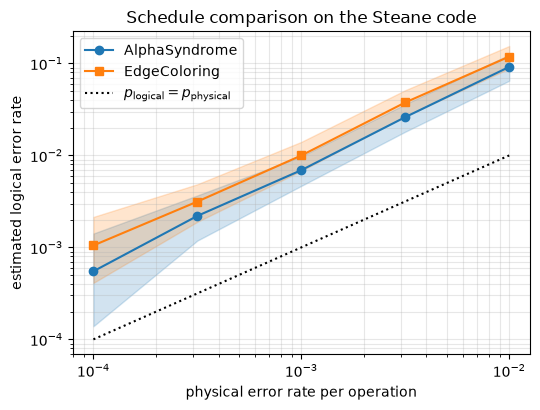

In [4]:
code = codes.SteaneCode()
# Decoder choice can strongly affect both the learned schedule and the reported error rates.
decoder_spec = decoders.bp_lsd(
    max_iter=30,
    bp_method="ms",
    ms_scaling_factor=0.625,
    lsd_method="LSD_CS",
    lsd_order=1,
    always_run_lsd=True,
)

noise_model = circuits.DepolarizingNoiseModel(10e-3)  # noise model used to train AlphaSyndrome
decoder = decoders.SinterDecoder(decoder=decoder_spec)
strategies = [
    circuits.EdgeColoring(),
    circuits.AlphaSyndrome(
        noise_model,
        decoder=decoder,
        iters_per_step=30,
        shots_per_iter=2_000,
        verbose=False,
        seed=0,
    ),
]

make_memory_experiment_figure(code, strategies, num_rounds=3, decoder=decoder_spec)
plt.show()

The plot compares the schedule returned by this bounded search with the default edge-coloring schedule using the same decoder for both.
A lower learned-schedule estimate at one sampled rate is evidence about this run, not proof that the schedule is globally optimal or better at every rate.
